## Hindsight Optimal Trades (BTC) — Data Exploration

- This notebook explores the dataset at `research/regret_minimization/data/hindsight_optimal_trades_btc.parquet`.
- It prints Parquet metadata + schema, loads into pandas, and computes basic data quality + trading-focused summaries.


In [1]:
# Setup: imports and display options
import json
import math
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

sns.set_theme(context="notebook", style="whitegrid")


def format_bytes(num_bytes: int) -> str:
    if num_bytes is None or pd.isna(num_bytes):
        return "NA"
    units = ["B", "KB", "MB", "GB", "TB"]
    size = float(num_bytes)
    for unit in units:
        if size < 1024:
            return f"{size:.2f} {unit}"
        size /= 1024
    return f"{size:.2f} PB"


# Resolve repo root robustly (Jupyter's CWD may be inside `research/regret_minimization`)
NOTEBOOK_DIR = Path.cwd().resolve()


def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / ".git").exists():
            return p
        # Heuristic for this repo layout
        if (p / "research").exists() and (p / "GP").exists():
            return p
    return start


PROJECT_ROOT = find_repo_root(NOTEBOOK_DIR)

PARQUET_CANDIDATES = [
    PROJECT_ROOT / "research" / "regret_minimization" / "data" / "hindsight_optimal_trades_btc.parquet",
    # If you opened the notebook from within `research/regret_minimization/`
    NOTEBOOK_DIR / "data" / "hindsight_optimal_trades_btc.parquet",
    Path("research/regret_minimization/data/hindsight_optimal_trades_btc.parquet").resolve(),
]

for p in PARQUET_CANDIDATES:
    if p.exists():
        PARQUET_PATH = p
        break
else:
    raise FileNotFoundError(
        "Could not find parquet file. Tried:\n" + "\n".join(str(x) for x in PARQUET_CANDIDATES)
    )

print("NOTEBOOK_DIR:", NOTEBOOK_DIR)
print("PROJECT_ROOT:", PROJECT_ROOT)
PARQUET_PATH

NOTEBOOK_DIR: C:\Users\DELL\Projects\nof1\trading-env\research\regret_minimization\data
PROJECT_ROOT: C:\Users\DELL\Projects\nof1\trading-env


WindowsPath('C:/Users/DELL/Projects/nof1/trading-env/research/regret_minimization/data/hindsight_optimal_trades_btc.parquet')

In [2]:
# Fast Parquet metadata + Arrow schema (no full load)
import pyarrow as pa
import pyarrow.parquet as pq

pf = pq.ParquetFile(str(PARQUET_PATH))

print({
    "path": str(PARQUET_PATH),
    "rows": pf.metadata.num_rows if pf.metadata else None,
    "row_groups": pf.num_row_groups,
})

print("\nArrow schema:\n")
print(pf.schema_arrow)

{'path': 'C:\\Users\\DELL\\Projects\\nof1\\trading-env\\research\\regret_minimization\\data\\hindsight_optimal_trades_btc.parquet', 'rows': 43610, 'row_groups': 1}

Arrow schema:

coin: string
decision_timestamp: timestamp[ns]
state_json: string
close: double
ret_15m: double
rv_15m: double
funding: double
funding_z_7d: double
ofi_1m: double
impact_skew_bps: double
open_interest: double
hour: int64
dow: int64
is_gap_fill: int64
trade_count: int64
action: string
no_trade_reason: string
gross_pnl_pct: double
net_pnl_pct: double
entry_price: double
ideal_exit_price: double
time_to_peak_minutes: double
max_adverse_excursion_pct: double
long_potential_pct: double
short_potential_pct: double
direction_edge_pct: double
-- schema metadata --
pandas: '{"index_columns": [], "column_indexes": [], "columns": [{"name":' + 3297


In [3]:
# Load into pandas

df = pd.read_parquet(PARQUET_PATH, engine="pyarrow")

print({
    "rows": int(df.shape[0]),
    "cols": int(df.shape[1]),
    "memory": format_bytes(int(df.memory_usage(deep=True).sum())),
})

display(df.head(10))
df.info()

{'rows': 43610, 'cols': 26, 'memory': '85.49 MB'}


,coin,decision_timestamp,state_json,close,ret_15m,rv_15m,funding,funding_z_7d,ofi_1m,impact_skew_bps,open_interest,hour,dow,is_gap_fill,trade_count,action,no_trade_reason,gross_pnl_pct,net_pnl_pct,entry_price,ideal_exit_price,time_to_peak_minutes,max_adverse_excursion_pct,long_potential_pct,short_potential_pct,direction_edge_pct
0,BTC,2024-08-01 00:00:00,"{""open"": 64666.0, ""high"": 64679.0, ""low"": 6466...",64672.0,-0.001823,0.001873,0.0,0.0,0.006005,0.0,0.0,0,3,0,8,no_trade,insufficient_move,0.250495,0.060495,64672.0,64834.0,11.0,0.049480,0.250495,0.049480,0.201014
1,BTC,2024-08-01 00:15:00,"{""open"": 64690.0, ""high"": 64693.0, ""low"": 6468...",64683.0,0.000170,0.001923,0.0,0.0,0.064596,0.0,0.0,0,3,0,15,short,None,0.394230,0.204230,64683.0,64428.0,13.0,0.180882,0.180882,0.394230,0.213348
2,BTC,2024-08-01 00:30:00,"{""open"": 64716.0, ""high"": 64720.0, ""low"": 6471...",64710.0,0.000417,0.003684,0.0,0.0,0.999981,0.0,0.0,0,3,0,18,no_trade,insufficient_move,0.262711,0.072711,64710.0,64880.0,10.0,0.159172,0.262711,0.159172,0.103539
3,BTC,2024-08-01 00:45:00,"{""open"": 64748.0, ""high"": 64748.0, ""low"": 6468...",64684.0,-0.000402,0.002686,0.0,0.0,0.997904,0.0,0.0,0,3,0,5,short,None,0.502443,0.312443,64684.0,64359.0,3.0,0.000000,0.047925,0.502443,0.454517
4,BTC,2024-08-01 01:00:00,"{""open"": 64709.0, ""high"": 64711.0, ""low"": 6467...",64676.0,-0.000124,0.003525,0.0,0.0,0.025015,0.0,0.0,1,3,0,7,no_trade,insufficient_move,0.252025,0.062025,64676.0,64839.0,5.0,0.037108,0.252025,0.199456,0.052570
5,BTC,2024-08-01 01:15:00,"{""open"": 64645.0, ""high"": 64674.0, ""low"": 6464...",64674.0,-0.000031,0.002562,0.0,0.0,0.713043,0.0,0.0,1,3,0,4,short,None,0.360268,0.170268,64674.0,64441.0,9.0,0.000000,-0.012370,0.360268,0.372638
6,BTC,2024-08-01 01:30:00,"{""open"": 64584.0, ""high"": 64585.0, ""low"": 6458...",64585.0,-0.001377,0.002118,0.0,0.0,0.460719,0.0,0.0,1,3,0,2,short,None,0.679724,0.489724,64585.0,64146.0,7.0,0.000000,-0.010838,0.679724,0.690563
7,BTC,2024-08-01 01:45:00,"{""open"": 64347.0, ""high"": 64457.0, ""low"": 6434...",64430.0,-0.002403,0.005082,0.0,0.0,0.055242,0.0,0.0,1,3,0,11,short,None,0.429924,0.239924,64430.0,64153.0,12.0,0.037250,0.037250,0.429924,0.392674
8,BTC,2024-08-01 02:00:00,"{""open"": 64190.0, ""high"": 64208.0, ""low"": 6418...",64208.0,-0.003452,0.002690,0.0,0.0,0.794637,0.0,0.0,2,3,0,11,short,None,0.456329,0.266329,64208.0,63915.0,7.0,0.056068,0.056068,0.456329,0.400262
9,BTC,2024-08-01 02:15:00,"{""open"": 64216.0, ""high"": 64225.0, ""low"": 6420...",64206.0,-0.000031,0.003687,0.0,0.0,0.000000,0.0,0.0,2,3,0,7,short,None,0.446999,0.256999,64206.0,63919.0,9.0,0.112139,0.112139,0.446999,0.334860


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43610 entries, 0 to 43609
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   coin                       43610 non-null  object        
 1   decision_timestamp         43610 non-null  datetime64[ns]
 2   state_json                 43610 non-null  object        
 3   close                      43610 non-null  float64       
 4   ret_15m                    43610 non-null  float64       
 5   rv_15m                     43610 non-null  float64       
 6   funding                    43610 non-null  float64       
 7   funding_z_7d               43610 non-null  float64       
 8   ofi_1m                     43610 non-null  float64       
 9   impact_skew_bps            43610 non-null  float64       
 10  open_interest              43610 non-null  float64       
 11  hour                       43610 non-null  int64         
 12  dow 

In [4]:
# Data quality: missing values, duplicates, constants

missing_counts = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing_counts / len(df) * 100).round(3)
missing_df = pd.DataFrame({"missing_count": missing_counts, "missing_pct": missing_pct})

summary = {
    "missing_total": int(missing_counts.sum()),
    "duplicate_rows": int(df.duplicated().sum()),
}

nunique = df.nunique(dropna=False)
summary["constant_cols"] = nunique[nunique <= 1].index.tolist()

print(json.dumps(summary, indent=2, default=str))

display(missing_df.head(20))
print("Duplicate rows:", summary["duplicate_rows"])
print("Constant columns:", summary["constant_cols"])

{
  "missing_total": 13136,
  "duplicate_rows": 0,
  "constant_cols": [
    "coin",
    "is_gap_fill"
  ]
}


,missing_count,missing_pct
no_trade_reason,12122,27.796
gross_pnl_pct,133,0.305
max_adverse_excursion_pct,133,0.305
net_pnl_pct,133,0.305
ideal_exit_price,133,0.305
time_to_peak_minutes,133,0.305
entry_price,133,0.305
long_potential_pct,72,0.165
direction_edge_pct,72,0.165
short_potential_pct,72,0.165


Duplicate rows: 0
Constant columns: ['coin', 'is_gap_fill']


In [5]:
# Time range + basic categorical distributions

if "decision_timestamp" in df.columns:
    ts = df["decision_timestamp"]
    print({
        "decision_timestamp_min": str(ts.min()),
        "decision_timestamp_max": str(ts.max()),
        "n_unique_timestamps": int(ts.nunique(dropna=True)),
    })

for c in ["coin", "action", "no_trade_reason"]:
    if c in df.columns:
        vc = df[c].fillna("<NA>").value_counts(dropna=False)
        display(vc.head(30).to_frame("count"))

{'decision_timestamp_min': '2024-08-01 00:00:00', 'decision_timestamp_max': '2025-10-31 23:45:00', 'n_unique_timestamps': 43610}


,count
coin,
BTC,43610


,count
action,
no_trade,31488
short,6131
long,5991


,count
no_trade_reason,
insufficient_move,31355
<NA>,12122
execution_delay_violation,72
exceeds_slice_duration,61


,net_pnl_pct
count,43477.000000
mean,0.066907
std,0.257394
min,-0.189085
1%,-0.157007
5%,-0.132017
25%,-0.072999
50%,-0.000466
75%,0.119805
95%,0.477774


,count,mean,median,min,max
action,,,,,
no_trade,31355,-0.037646,-0.043284,-0.189085,0.099986
short,6131,0.343066,0.238427,0.100018,9.755255
long,5991,0.331496,0.230190,0.100040,6.709973


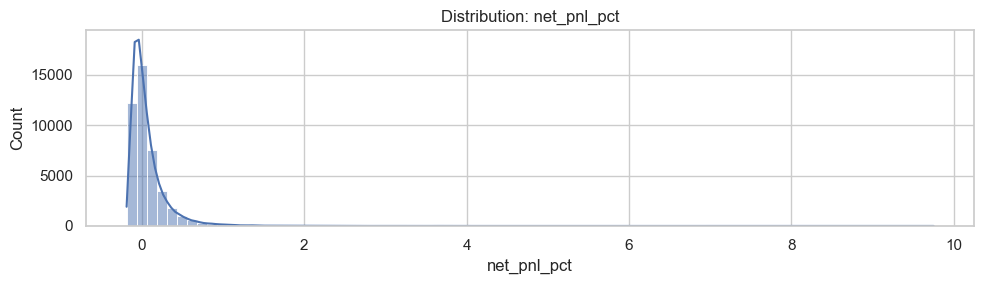

In [6]:
# PnL analysis

if "net_pnl_pct" in df.columns:
    pnl = df["net_pnl_pct"].dropna()

    display(pnl.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame("net_pnl_pct"))

    if "action" in df.columns:
        by_action = (
            df.groupby("action", dropna=False)["net_pnl_pct"]
            .agg(["count", "mean", "median", "min", "max"])
            .sort_values("count", ascending=False)
        )
        display(by_action)

    plt.figure(figsize=(10, 3))
    sns.histplot(pnl, bins=80, kde=True)
    plt.title("Distribution: net_pnl_pct")
    plt.tight_layout()
    plt.show()

,direction_edge_pct,long_potential_pct,short_potential_pct,max_adverse_excursion_pct,time_to_peak_minutes,net_pnl_pct
direction_edge_pct,1.000000,0.535377,0.604281,0.055333,0.147611,0.955655
long_potential_pct,0.535377,1.000000,-0.098360,0.329771,0.077313,0.616675
short_potential_pct,0.604281,-0.098360,1.000000,0.319969,0.071275,0.681581
max_adverse_excursion_pct,0.055333,0.329771,0.319969,1.000000,0.210931,0.296489
time_to_peak_minutes,0.147611,0.077313,0.071275,0.210931,1.000000,0.132642
net_pnl_pct,0.955655,0.616675,0.681581,0.296489,0.132642,1.000000


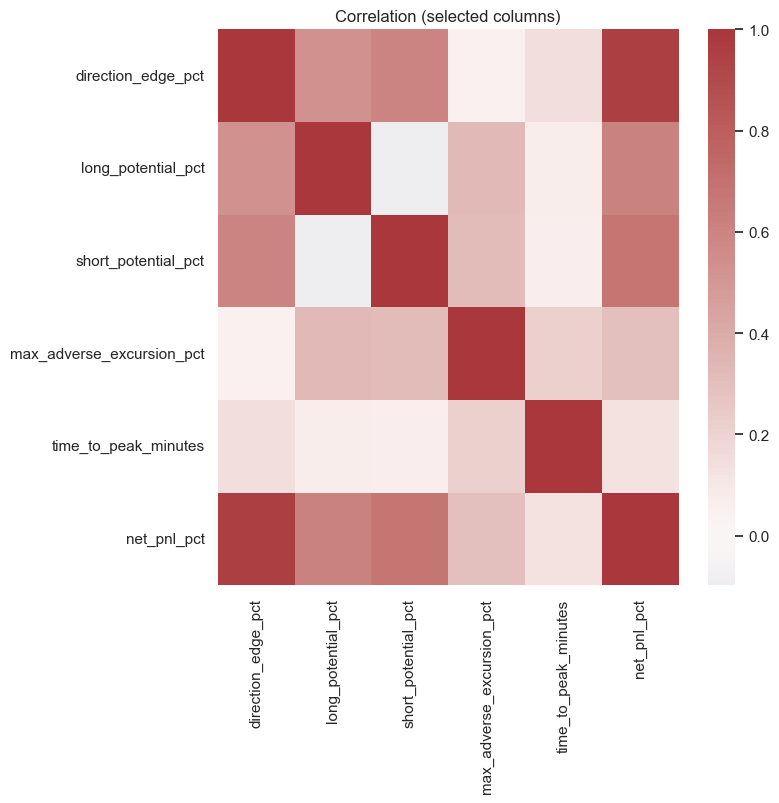

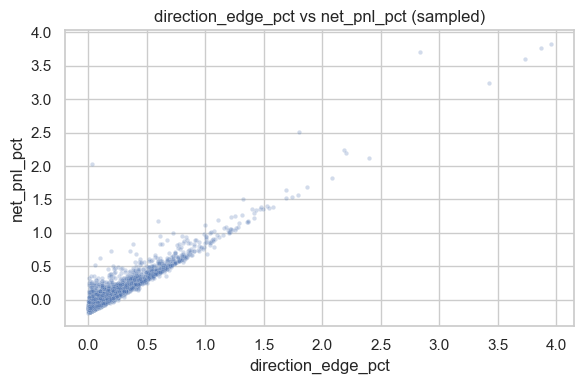

In [7]:
# Edge vs PnL (sanity check)

cols = [c for c in [
    "direction_edge_pct",
    "long_potential_pct",
    "short_potential_pct",
    "max_adverse_excursion_pct",
    "time_to_peak_minutes",
    "net_pnl_pct",
] if c in df.columns]

if len(cols) >= 2:
    corr = df[cols].corr(numeric_only=True)
    display(corr)

    plt.figure(figsize=(min(0.7 * len(cols) + 4, 14), min(0.7 * len(cols) + 4, 14)))
    sns.heatmap(corr, cmap="vlag", center=0)
    plt.title("Correlation (selected columns)")
    plt.tight_layout()
    plt.show()

if set(["direction_edge_pct", "net_pnl_pct"]).issubset(df.columns):
    tmp = df[["direction_edge_pct", "net_pnl_pct"]].dropna().sample(n=min(5000, len(df)), random_state=42)
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=tmp, x="direction_edge_pct", y="net_pnl_pct", s=10, alpha=0.25)
    plt.title("direction_edge_pct vs net_pnl_pct (sampled)")
    plt.tight_layout()
    plt.show()

In [8]:
# Inspect `state_json` (nested features) on a small sample

if "state_json" in df.columns:
    s = df["state_json"].dropna()
    print("non_null_state_json:", int(s.shape[0]))

    ex = json.loads(s.iloc[0])
    print("example keys (first 50):")
    print(list(ex.keys())[:50])

    # Parse a small sample of rows into columns (for inspection only)
    sample_n = min(200, len(s))
    sample_states = pd.json_normalize([json.loads(x) for x in s.sample(sample_n, random_state=42)])
    print("Parsed sample shape:", sample_states.shape)
    display(sample_states.head(5))
else:
    print("No state_json column found.")

non_null_state_json: 43610
example keys (first 50):
['open', 'high', 'low', 'close', 'volume', 'trade_count', 'ret_1m', 'ret_5m', 'ret_15m', 'ret_60m', 'ret_240m', 'rv_15m', 'rv_60m', 'rv_240m', 'range_bps', 'body_bps', 'upper_wick_bps', 'lower_wick_bps', 'close_loc', 'log_vol', 'vol_z_60m', 'trade_count_z_60m', 'trend_strength_60m', 'is_gap_fill', 'augmented_by_l2', 'mid_price', 'mark_price', 'oracle_price', 'funding', 'premium', 'open_interest', 'signed_vol', 'ofi_1m', 'buy_vol', 'sell_vol', 'liq_vol', 'impact_spread_bps', 'impact_skew_bps', 'ask_leg_bps', 'bid_leg_bps', 'funding_z_1d', 'funding_z_7d', 'funding_mom_60m', 'funding_mom_240m', 'oi_log', 'oi_chg_15m', 'oi_chg_60m', 'oi_chg_240m', 'oi_z_7d', 'd_impact_skew_5m']
Parsed sample shape: (200, 64)


,open,high,low,close,volume,trade_count,ret_1m,ret_5m,ret_15m,ret_60m,ret_240m,rv_15m,rv_60m,rv_240m,range_bps,body_bps,upper_wick_bps,lower_wick_bps,close_loc,log_vol,vol_z_60m,trade_count_z_60m,trend_strength_60m,is_gap_fill,augmented_by_l2,mid_price,mark_price,oracle_price,funding,premium,open_interest,signed_vol,ofi_1m,buy_vol,sell_vol,liq_vol,impact_spread_bps,impact_skew_bps,ask_leg_bps,bid_leg_bps,funding_z_1d,funding_z_7d,funding_mom_60m,funding_mom_240m,oi_log,oi_chg_15m,oi_chg_60m,oi_chg_240m,oi_z_7d,d_impact_skew_5m,impact_skew_z_60m,timestamp_iso,hour,minute_of_day,dow,is_weekend,day_of_month,month,is_asia_session,is_europe_session,is_us_session,hours_until_funding,is_near_funding,basis_funding_interaction
0,57935.0,57972.0,57906.0,57962.0,8.89063,37,0.000328,-0.001517,-0.001620,-0.001259,-0.004321,0.002001,0.004204,0.006924,11.386771,4.658224,1.725268,5.003278,0.848485,2.291588,2.432462,1.804988,-0.299387,0,0,0.0,0.0,0.0,0.000000,0.000000,0.00000,7.92935,0.891877,7.92935,0.0,8.89063,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-27.631021,0.000000,0.000000,0.000000,-0.191847,0.000000,0.000000,2024-09-01T12:45:00Z,12,765,6,1,1,9,0,1,0,4,0,NaN
1,109230.5,109231.0,109155.0,109179.5,0.00000,0,-0.000467,-0.001254,-0.001775,-0.000646,-0.002657,0.000754,0.001981,0.002949,6.961014,4.671207,0.045796,2.244011,0.322368,0.000000,-0.774494,-1.104453,-0.325801,0,1,109179.5,109184.0,109237.0,0.000005,-0.000448,32089.10354,0.00000,0.000000,0.00000,0.0,0.00000,0.833490,0.741898,0.787694,0.045796,-1.727021,-1.300980,-0.000003,-0.000002,10.376272,-0.000272,-0.000183,-0.000313,0.073114,0.815080,2.512930,2025-09-28T12:45:00Z,12,765,6,1,28,9,0,1,0,4,0,8.379224
2,111105.0,111165.0,111102.0,111144.0,4.17354,106,0.000342,-0.001016,0.000270,-0.000854,-0.006868,0.001874,0.003200,0.008135,5.668322,3.508961,1.889441,0.269920,0.666667,1.643557,-0.530685,-0.396636,-0.267019,0,0,111150.5,111147.0,111109.0,0.000013,0.000299,32387.57052,2.66396,0.638297,2.66396,0.0,0.01884,0.791719,-0.701751,0.044984,0.746735,-1.156765,-0.082110,0.000000,0.000000,10.385530,0.000194,-0.004110,-0.026754,0.127671,-0.701751,-1.941476,2025-08-25T11:45:00Z,11,705,0,0,25,8,0,1,0,5,0,-3.956210
3,58263.0,58263.0,58232.0,58239.0,1.88700,17,-0.000463,-0.003685,-0.002367,-0.000618,-0.004916,0.002401,0.004937,0.007789,5.322894,4.120950,0.000000,1.201944,0.225806,1.060218,0.851038,1.051496,-0.125172,0,0,0.0,0.0,0.0,0.000000,0.000000,0.00000,1.00304,0.531553,1.00304,0.0,1.88700,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-27.631021,0.000000,0.000000,0.000000,-0.191847,0.000000,0.000000,2024-08-16T12:15:00Z,12,735,4,0,16,8,0,1,0,4,0,NaN
4,104666.0,104672.0,104666.0,104672.0,3.63211,73,0.000057,0.000134,0.000602,0.001396,-0.004547,0.000549,0.001910,0.004068,0.573219,0.573219,0.000000,0.000000,1.000000,1.533012,0.001440,-0.245735,0.730950,0,0,104671.5,104670.0,104675.0,0.000013,-0.000029,24090.17354,1.81350,0.499297,1.81350,0.0,3.63211,0.095537,0.000000,0.047768,0.047768,0.306594,0.012888,0.000000,0.000000,10.089559,-0.000057,0.003930,-0.001003,-0.002111,0.000000,-0.185633,2025-06-05T09:00:00Z,9,540,3,0,5,6,0,1,0,7,0,-0.146451


In [ ]:
# Optional: sample export

SAMPLE_N = 200
OUT_CSV = Path("results/hindsight_optimal_trades_btc_sample.csv")

sample_df = df.sample(n=min(SAMPLE_N, len(df)), random_state=42)
display(sample_df.head(10))

OUT_CSV.parent.mkdir(parents=True, exist_ok=True)
sample_df.to_csv(OUT_CSV, index=False)
print("Wrote:", OUT_CSV.resolve())

,coin,decision_timestamp,state_json,close,ret_15m,rv_15m,funding,funding_z_7d,ofi_1m,impact_skew_bps,open_interest,hour,dow,is_gap_fill,trade_count,action,no_trade_reason,gross_pnl_pct,net_pnl_pct,entry_price,ideal_exit_price,time_to_peak_minutes,max_adverse_excursion_pct,long_potential_pct,short_potential_pct,direction_edge_pct
3025,BTC,2024-09-01 12:45:00,"{""open"": 57935.0, ""high"": 57972.0, ""low"": 5790...",57962.0,-0.001620,0.002001,0.000000,0.000000,0.891877,0.000000,0.00000,12,6,0,37,no_trade,insufficient_move,0.082813,-0.107187,57962.0,58010.0,3.0,0.000000,0.082813,0.072461,0.010352
40643,BTC,2025-09-28 12:45:00,"{""open"": 109230.5, ""high"": 109231.0, ""low"": 10...",109179.5,-0.001775,0.000754,0.000005,-1.300980,0.000000,0.741898,32089.10354,12,6,0,0,no_trade,insufficient_move,0.098462,-0.091538,109179.5,109287.0,12.0,0.031599,0.098462,0.031599,0.066862
37375,BTC,2025-08-25 11:45:00,"{""open"": 111105.0, ""high"": 111165.0, ""low"": 11...",111144.0,0.000270,0.001874,0.000013,-0.082110,0.638297,-0.701751,32387.57052,11,0,0,106,no_trade,insufficient_move,0.169150,-0.020850,111144.0,111332.0,9.0,0.006298,0.169150,0.006298,0.162852
1487,BTC,2024-08-16 12:15:00,"{""open"": 58263.0, ""high"": 58263.0, ""low"": 5823...",58239.0,-0.002367,0.002401,0.000000,0.000000,0.531553,0.000000,0.00000,12,4,0,17,short,None,0.422397,0.232397,58239.0,57993.0,9.0,0.051512,0.051512,0.422397,0.370885
29597,BTC,2025-06-05 09:00:00,"{""open"": 104666.0, ""high"": 104672.0, ""low"": 10...",104672.0,0.000602,0.000549,0.000013,0.012888,0.499297,0.000000,24090.17354,9,3,0,73,no_trade,insufficient_move,0.113688,-0.076312,104672.0,104791.0,8.0,0.000955,0.113688,0.000955,0.112733
8869,BTC,2024-11-01 10:00:00,"{""open"": 69577.0, ""high"": 69578.0, ""low"": 6957...",69573.0,0.000029,0.000921,0.000000,0.000000,0.802817,0.000000,0.00000,10,4,0,4,no_trade,insufficient_move,0.168169,-0.021831,69573.0,69690.0,12.0,0.011499,0.168169,0.011499,0.156670
42508,BTC,2025-10-18 19:45:00,"{""open"": 107016.0, ""high"": 107034.0, ""low"": 10...",106971.0,0.000187,0.000957,0.000013,0.344513,0.714332,0.130876,25532.98886,19,5,0,109,no_trade,insufficient_move,0.091614,-0.098386,106971.0,107069.0,3.0,0.000000,0.091614,-0.003739,0.095353
11433,BTC,2024-11-28 03:00:00,"{""open"": 95709.0, ""high"": 95779.0, ""low"": 9570...",95749.0,-0.004772,0.002326,0.000000,0.000000,0.041016,0.000000,0.00000,3,3,0,64,short,None,0.331074,0.141074,95749.0,95432.0,11.0,0.083552,0.083552,0.331074,0.247522
9549,BTC,2024-11-08 12:00:00,"{""open"": 76057.0, ""high"": 76057.0, ""low"": 7602...",76022.0,-0.002076,0.001020,0.000000,0.000000,0.924039,0.000000,0.00000,12,4,0,99,no_trade,insufficient_move,0.128910,-0.061090,76022.0,76120.0,8.0,0.006577,0.128910,0.015785,0.113125
2111,BTC,2024-08-23 00:15:00,"{""open"": 60528.0, ""high"": 60528.0, ""low"": 6052...",60525.0,0.002233,0.001891,0.000000,0.000000,0.427634,0.000000,0.00000,0,4,0,7,long,None,0.307311,0.117311,60525.0,60711.0,15.0,0.004957,0.307311,0.004957,0.302354


Wrote: C:\Users\DELL\Projects\nof1\trading-env\research\regret_minimization\data\research\regret_minimization\results\hindsight_optimal_trades_btc_sample.csv
